# Malaria model ranking

Multi-criteria ranking of malaria scam fits. Loads per-task summary CSVs
from a `scam_fits` run, lets you pick which metrics to rank on, runs
Kendall τ on the chosen metrics, then Borda / TOPSIS / Pareto / pairwise
dominance, and surfaces a winners-by-method comparison.

Mirrors `dh_final_diagnostics.ipynb` from idd-tc-mortality.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    NO_FE_METRICS,
    CALIBRATION_METRICS,
    kendall_tau_heatmap,
    borda_rank,
    topsis_rank,
    pareto_frontier,
    pairwise_dominance_summary,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

## Paths

Edit `FIT_OUTPUT_DIR` to point at the scam_fits run you want to rank.
Each task writes one `*summary*.csv` in this dir; the load cell
concatenates them.

In [2]:
FIT_OUTPUT_DIR = Path(
    '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260512_v2'
)

assert FIT_OUTPUT_DIR.exists(), f'Missing: {FIT_OUTPUT_DIR}'
summary_files = sorted(FIT_OUTPUT_DIR.glob('*summary*.csv'))
print(f'Found {len(summary_files)} summary CSVs in {FIT_OUTPUT_DIR}')

Found 210 summary CSVs in /mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260512_v2


## Load

One row per task. Columns described in `model_selection.py` module docstring.

In [3]:
df = pd.concat(
    [pd.read_csv(p) for p in summary_files],
    ignore_index=True,
)


In [4]:

# Filter out all rows where 'urban' is in the formula, since we know those models are bad:
urban_mask = df['formula_text'].str.contains('urban', case=False, na=False)
df = df[~urban_mask].copy()
print(f'After urban cull: {len(df):,} tasks')


metric_df = df[CONFIG_COLS + list(DEFAULT_METRICS.keys()) + list(NO_FE_METRICS.keys())]

print(f'metric_df: {metric_df.shape[0]:,} rows × {metric_df.shape[1]} cols')
print(f'task_id range: {metric_df["task_id"].min()} .. {metric_df["task_id"].max()}')
print(f'duplicate task_ids: {metric_df["task_id"].duplicated().sum()}')
metric_df.head()

After urban cull: 30 tasks
metric_df: 30 rows × 25 cols
task_id range: 1 .. 204
duplicate task_ids: 0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
7,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566
14,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489
21,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208
28,29,1.400311e+06,1.401100e+06,2.225497e+06,0.826386,0.826386,2.787359,1.963857,5.756651,4.702661,0.259475,0.089444,0.037161,0.850704,0.179761,0.083664,0.180550,1.735117e+06,1.735169e+06,0.440999,0.440999,5.001571,4.047076,0.081433,0.354626


## Optional cull

Drop tasks with any non-finite ranking metric (failed fits). Tighter
performance gates (e.g. `oos_pfpr_r > 0.15`, `oos_mae < 4.5` from the qmd)
are commented out — uncomment if you want to limit the candidate pool
before ranking.

In [5]:
print(f'Before cull: {len(metric_df):,} tasks')

rank_cols = [c for c in DEFAULT_METRICS if c in metric_df.columns]
finite_mask = np.isfinite(metric_df[rank_cols].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
metric_df = metric_df[finite_mask].copy()
print(f'After non-finite cull: {len(metric_df):,} tasks ({n_failed:,} dropped)')

# Performance gates — uncomment to apply:
# metric_df = metric_df[metric_df['oos_pfpr_r'] > 0.15].copy()
# metric_df = metric_df[metric_df['oos_mae']    < 4.5 ].copy()
# print(f'After performance gates: {len(metric_df):,} tasks')



Before cull: 30 tasks
After non-finite cull: 30 tasks (0 dropped)


## Pick metrics

Edit `metrics_to_use` — comment / uncomment lines to define the ranking
set. Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better

In [6]:
metrics_to_use = {
    # ---- In-sample (with fixed effects) ----
    # 'is_aic':        'lower',
    # 'is_bic':        'lower',
    # 'is_deviance':   'lower',
    # 'is_dev_expl':   'higher',
    'is_r_sq':       'higher',
    # 'is_rmse':       'lower',
    # 'is_mae':        'lower',

    # ---- In-sample PfPR ----
    # 'is_pfpr_rmse':  'lower',
    # 'is_pfpr_mae':   'lower',
    'is_pfpr_r':     'higher',

    # ---- Out-of-sample ----
    # 'oos_rmse':      'lower',
    # 'oos_mae':       'lower',
    'oos_r_sq':      'higher',

    # ---- Out-of-sample PfPR ----
    # 'oos_pfpr_rmse': 'lower',
    # 'oos_pfpr_mae':  'lower',
    'oos_pfpr_r':    'higher',

    # ---- No-FE metrics ----
    # 'is_no_fe_aic':  'lower',
    # 'is_no_fe_bic':  'lower',
    # 'is_no_fe_dev_expl': 'higher',
    'is_no_fe_r_sq': 'higher',
    # 'is_no_fe_rmse': 'lower',
    # 'is_no_fe_mae':  'lower',
    # 'is_no_fe_pfpr_mae':   'lower',
    'is_no_fe_pfpr_r':     'higher',
}

metrics_present = {k: v for k, v in metrics_to_use.items() if k in metric_df.columns}
calib_present   = [c for c in CALIBRATION_METRICS if c in metric_df.columns]

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:18s}  {d}')

missing = [k for k in metrics_to_use if k not in metric_df.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in metric_df (skipped): {missing}')

Active rank metrics (6):
  is_r_sq             higher
  is_pfpr_r           higher
  oos_r_sq            higher
  oos_pfpr_r          higher
  is_no_fe_r_sq       higher
  is_no_fe_pfpr_r     higher


## Kendall τ — metric correlation

Rank correlation between each pair of selected metrics. Tightly correlated
metrics (high τ) add no independent ranking information. Drop redundant
ones from `metrics_to_use` above and re-run.

Kendall τ on 30 tasks × 6 metrics


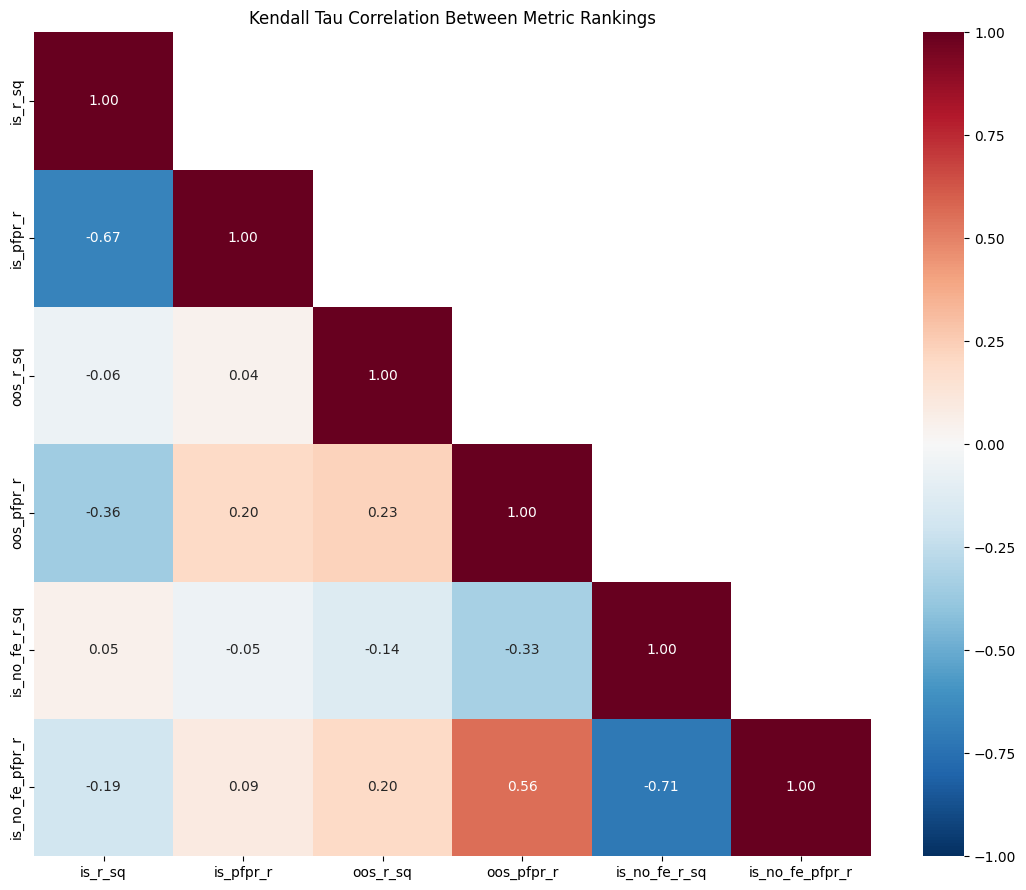


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: -0.076
Pairs with negative correlation: 8
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [7]:
print(f'Kendall τ on {len(metric_df):,} tasks × {len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(metric_df, metrics_present, calib_present, figsize=(11, 9))
plt.show()

## Borda count

Sum-of-ranks across metrics, with an auto-detected elbow / cutpoint for
where the top tier ends.

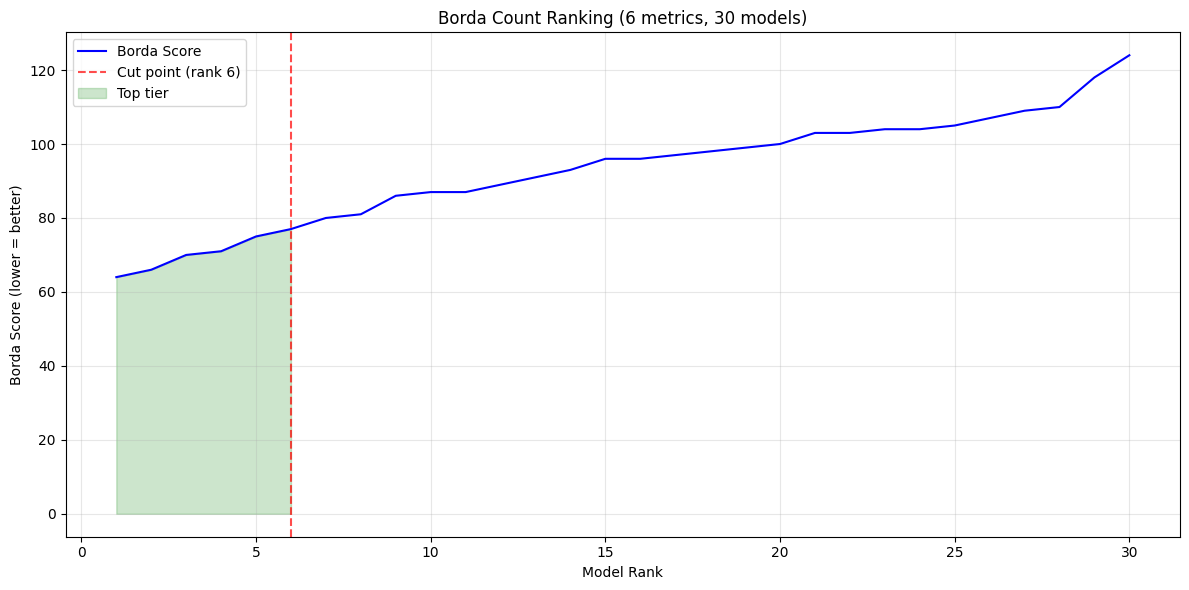


=== Borda Count Summary ===
Total models: 30
Metrics used: 6
Suggested cutpoint: rank 6 (top 6 models)
Top tier Borda range: 64.0 - 77.0
Bottom tier starts at: 80.0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,borda_score,borda_rank
0,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,64.0,1.0
1,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,66.0,2.0
2,141,1.396043e+06,1.396867e+06,2.192532e+06,0.828957,0.828957,2.766638,1.978831,5.615492,4.590520,0.295347,0.105303,0.043206,0.806114,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689,70.0,3.0
3,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208,71.0,4.0
4,162,1.395766e+06,1.396612e+06,2.190382e+06,0.829125,0.829125,2.765281,1.978343,5.621688,4.604527,0.293791,0.105627,0.043352,0.805193,0.179256,0.082839,0.208222,1.733661e+06,1.733739e+06,0.443841,0.443841,4.988837,4.038478,0.081084,0.361706,75.0,5.0
5,120,1.403543e+06,1.404336e+06,2.250736e+06,0.824417,0.824417,2.803120,1.995467,5.727673,4.667600,0.266912,0.098323,0.041139,0.829618,0.179444,0.082787,0.239054,1.733886e+06,1.733949e+06,0.443399,0.443399,4.990822,4.029089,0.081431,0.374492,77.0,6.0
6,71,1.403642e+06,1.404425e+06,2.251531e+06,0.824355,0.824355,2.803615,1.995683,5.739516,4.680288,0.263877,0.098086,0.041056,0.830462,0.179352,0.082747,0.243650,1.734383e+06,1.734436e+06,0.442428,0.442428,4.995170,4.040022,0.081469,0.373754,80.0,7.0
7,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489,81.0,8.0
8,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566,86.0,9.0
9,148,1.396036e+06,1.396871e+06,2.192457e+06,0.828963,0.828963,2.766591,1.978306,5.645264,4.622948,0.287855,0.105206,0.043160,0.806539,0.179722,0.083108,0.191787,1.735650e+06,1.735703e+06,0.439957,0.439957,5.006229,4.054249,0.081301,0.383567,87.0,10.5


In [8]:
borda_df, borda_cutpoint = borda_rank(metric_df, metrics_present, calib_present)
borda_df.head(10)

## TOPSIS

Distance-to-ideal scoring with min-max normalisation (equal influence per metric). `influence` reports per-metric separation power.

In [9]:
topsis_df, influence = topsis_rank(metric_df, metrics_present, calib_present, verbose=True)
topsis_df.head(10)


=== TOPSIS Ranking (normalize=minmax) ===
Models ranked: 30
Metrics used: 6

Top 10 by TOPSIS:
   topsis_rank  topsis_score   is_r_sq  is_pfpr_r  oos_r_sq  oos_pfpr_r  is_no_fe_r_sq
0          1.0      0.591918  0.819307   0.871073  0.293681    0.208711       0.443798
1          2.0      0.585790  0.818854   0.875502  0.295347    0.255125       0.439616
2          3.0      0.583069  0.824388   0.831393  0.295347    0.255126       0.439616
3          4.0      0.575924  0.829125   0.805193  0.293791    0.208222       0.443841
4          5.0      0.574002  0.828957   0.806114  0.295347    0.255126       0.439615
5          6.0      0.565136  0.818861   0.875177  0.289340    0.198037       0.442067
6          7.0      0.553147  0.824417   0.829618  0.266912    0.239054       0.443399
7          8.0      0.548769  0.828842   0.805842  0.289376    0.198621       0.442071
8          9.0      0.545768  0.818862   0.875182  0.287855    0.191786       0.439957
9         10.0      0.538876  0.82

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,topsis_score,topsis_rank
0,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208,0.591918,1.0
1,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,0.585790,2.0
2,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,0.583069,3.0
3,162,1.395766e+06,1.396612e+06,2.190382e+06,0.829125,0.829125,2.765281,1.978343,5.621688,4.604527,0.293791,0.105627,0.043352,0.805193,0.179256,0.082839,0.208222,1.733661e+06,1.733739e+06,0.443841,0.443841,4.988837,4.038478,0.081084,0.361706,0.575924,4.0
4,141,1.396043e+06,1.396867e+06,2.192532e+06,0.828957,0.828957,2.766638,1.978831,5.615492,4.590520,0.295347,0.105303,0.043206,0.806114,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689,0.574002,5.0
5,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489,0.565136,6.0
6,120,1.403543e+06,1.404336e+06,2.250736e+06,0.824417,0.824417,2.803120,1.995467,5.727673,4.667600,0.266912,0.098323,0.041139,0.829618,0.179444,0.082787,0.239054,1.733886e+06,1.733949e+06,0.443399,0.443399,4.990822,4.029089,0.081431,0.374492,0.553147,7.0
7,155,1.396233e+06,1.397039e+06,2.194011e+06,0.828842,0.828842,2.767571,1.979515,5.639233,4.622893,0.289376,0.105367,0.043223,0.805842,0.179589,0.083137,0.198621,1.734569e+06,1.734634e+06,0.442071,0.442071,4.996770,4.048392,0.081259,0.370458,0.548769,8.0
8,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566,0.545768,9.0
9,71,1.403642e+06,1.404425e+06,2.251531e+06,0.824355,0.824355,2.803615,1.995683,5.739516,4.680288,0.263877,0.098086,0.041056,0.830462,0.179352,0.082747,0.243650,1.734383e+06,1.734436e+06,0.442428,0.442428,4.995170,4.040022,0.081469,0.373754,0.538876,10.0


## Pareto frontier

Non-dominated set: tasks that no other task strictly beats on every
metric. Large frontiers mean genuine trade-offs across metrics; small
frontiers mean a few tasks dominate the field.

In [10]:
pareto_df = pareto_frontier(metric_df, metrics_present, calib_present)
print(f'\nFrontier size: {len(pareto_df):,} / {len(metric_df):,} '
      f'({100 * len(pareto_df) / len(metric_df):.1f}%)')
pareto_df.head(10)


=== Pareto Frontier ===
Total models: 30
Non-dominated: 30 (100.0%)
Dominated: 0

Frontier size: 30 / 30 (100.0%)


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
7,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566
14,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489
21,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208
28,29,1.400311e+06,1.401100e+06,2.225497e+06,0.826386,0.826386,2.787359,1.963857,5.756651,4.702661,0.259475,0.089444,0.037161,0.850704,0.179761,0.083664,0.180550,1.735117e+06,1.735169e+06,0.440999,0.440999,5.001571,4.047076,0.081433,0.354626
35,36,1.396136e+06,1.396954e+06,2.193250e+06,0.828901,0.828901,2.767091,1.969550,5.672807,4.642897,0.280889,0.097640,0.040594,0.829576,0.180941,0.084507,0.133571,1.734984e+06,1.735080e+06,0.441274,0.441274,5.000338,4.045033,0.081502,0.341017
42,43,1.396915e+06,1.397718e+06,2.199245e+06,0.828434,0.828434,2.770870,1.969926,5.749756,4.702207,0.261248,0.097101,0.040197,0.830250,0.180193,0.083968,0.165086,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689
49,50,1.405760e+06,1.406548e+06,2.268237e+06,0.823051,0.823051,2.813997,1.989714,5.758112,4.706454,0.259099,0.092985,0.038846,0.840931,0.179186,0.082734,0.244991,1.735302e+06,1.735355e+06,0.440636,0.440636,5.003194,4.051878,0.081394,0.381182
56,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
63,64,1.405760e+06,1.406548e+06,2.268237e+06,0.823051,0.823051,2.813997,1.989714,5.835481,4.764368,0.239055,0.092985,0.038846,0.840931,0.179158,0.082670,0.249322,1.735380e+06,1.735433e+06,0.440485,0.440485,5.003869,4.052104,0.081358,0.384280


## Pairwise dominance

For each pair (A, B), A beats B if A wins on a majority of metrics.
`dominance_count` = how many tasks each task beats.

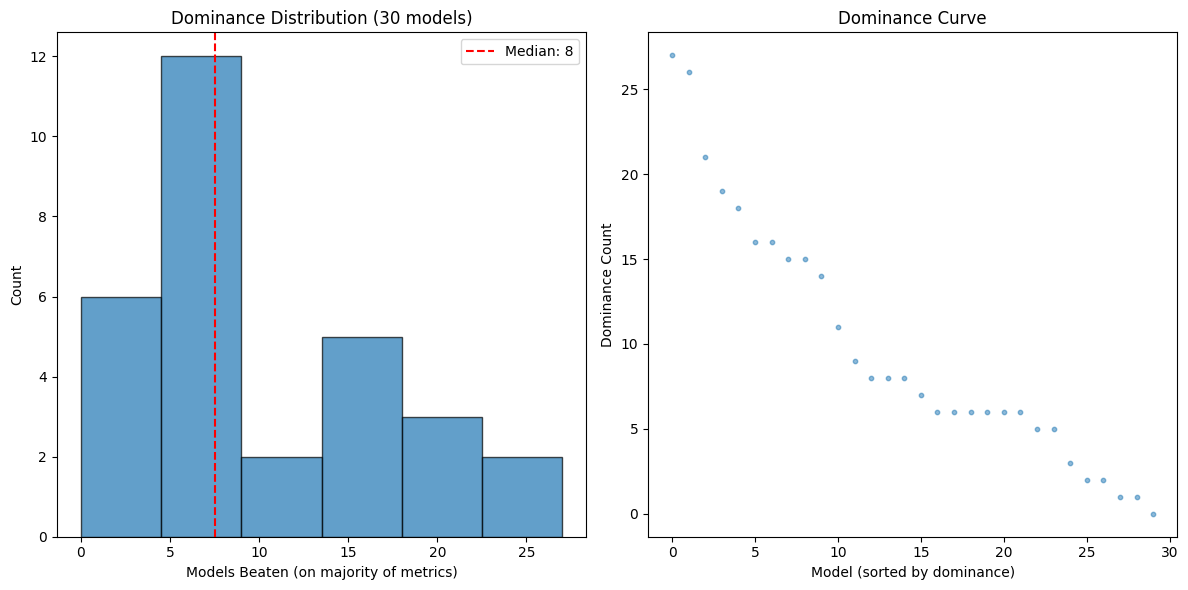


=== Pairwise Dominance Summary ===
Models compared: 30
Metrics used: 6
Max dominance: 27 / 29 models beaten
Median dominance: 8

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  task_id
0             1.0               27      93.103448        1
1             2.0               26      89.655172       57
2             3.0               21      72.413793      141
3             4.0               19      65.517241       22
4             5.0               18      62.068966      162
5             6.5               16      55.172414       15
6             6.5               16      55.172414      120
7             8.5               15      51.724138      155
8             8.5               15      51.724138       71
9            10.0               14      48.275862        8


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,dominance_count,dominance_pct,total_metric_wins,dominance_rank
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,27,93.103448,114,1.0
1,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,26,89.655172,116,2.0
2,141,1.396043e+06,1.396867e+06,2.192532e+06,0.828957,0.828957,2.766638,1.978831,5.615492,4.590520,0.295347,0.105303,0.043206,0.806114,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689,21,72.413793,110,3.0
3,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208,19,65.517241,109,4.0
4,162,1.395766e+06,1.396612e+06,2.190382e+06,0.829125,0.829125,2.765281,1.978343,5.621688,4.604527,0.293791,0.105627,0.043352,0.805193,0.179256,0.082839,0.208222,1.733661e+06,1.733739e+06,0.443841,0.443841,4.988837,4.038478,0.081084,0.361706,18,62.068966,105,5.0
5,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489,16,55.172414,99,6.5
6,120,1.403543e+06,1.404336e+06,2.250736e+06,0.824417,0.824417,2.803120,1.995467,5.727673,4.667600,0.266912,0.098323,0.041139,0.829618,0.179444,0.082787,0.239054,1.733886e+06,1.733949e+06,0.443399,0.443399,4.990822,4.029089,0.081431,0.374492,16,55.172414,103,6.5
7,155,1.396233e+06,1.397039e+06,2.194011e+06,0.828842,0.828842,2.767571,1.979515,5.639233,4.622893,0.289376,0.105367,0.043223,0.805842,0.179589,0.083137,0.198621,1.734569e+06,1.734634e+06,0.442071,0.442071,4.996770,4.048392,0.081259,0.370458,15,51.724138,93,8.5
8,71,1.403642e+06,1.404425e+06,2.251531e+06,0.824355,0.824355,2.803615,1.995683,5.739516,4.680288,0.263877,0.098086,0.041056,0.830462,0.179352,0.082747,0.243650,1.734383e+06,1.734436e+06,0.442428,0.442428,4.995170,4.040022,0.081469,0.373754,15,51.724138,100,8.5
9,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566,14,48.275862,94,10.0


In [11]:
dominance_df = pairwise_dominance_summary(metric_df, metrics_present, calib_present)
dominance_df.head(10)

## Winners by method

Side-by-side comparison of the top pick from each method on a shared
metric set. Pareto frontier has no canonical order — `pareto_first` is
the first row of the frontier (df order), not a "best" frontier member.

In [12]:
winners = {
    'borda':              borda_df.iloc[0],
    'topsis':             topsis_df.iloc[0],
    'pareto_first':       pareto_df.iloc[0],
    'pairwise_dominance': dominance_df.iloc[0],
}

show_cols = [k for k in metrics_present.keys()] + [c for c in CONFIG_COLS if c in metric_df.columns] +  ['is_aic', 'is_bic', 'is_dev_expl', 
    'oos_rmse', 'oos_mae']
show_cols = [c for c in show_cols if c in metric_df.columns]

winners_df = pd.DataFrame({k: w[show_cols] for k, w in winners.items()}).T
winners_df['selection_method'] = winners_df.index   # capture here
winners_df = winners_df.merge(dominance_df[['task_id', 'dominance_rank']], on='task_id')
winners_df = winners_df.merge(topsis_df[['task_id', 'topsis_rank']], on='task_id')
winners_df = winners_df.merge(borda_df[['task_id', 'borda_rank']], on='task_id')
winners_df = winners_df.set_index('selection_method')
winners_df

,is_r_sq,is_pfpr_r,oos_r_sq,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_pfpr_r,task_id,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,dominance_rank,topsis_rank,borda_rank
selection_method,,,,,,,,,,,,,,,
borda,0.824388,0.831393,0.295347,0.255126,0.439616,0.387688,57.0,1.403598e+06,1.404434e+06,0.824388,5.615492,4.590519,2.0,3.0,1.0
topsis,0.819307,0.871073,0.293681,0.208711,0.443798,0.362208,22.0,1.411760e+06,1.412560e+06,0.819307,5.622123,4.604915,4.0,1.0,4.0
pareto_first,0.818854,0.875502,0.295347,0.255125,0.439616,0.387688,1.0,1.412473e+06,1.413252e+06,0.818854,5.615491,4.590519,1.0,2.0,2.0
pairwise_dominance,0.818854,0.875502,0.295347,0.255125,0.439616,0.387688,1.0,1.412473e+06,1.413252e+06,0.818854,5.615491,4.590519,1.0,2.0,2.0


In [16]:
task_id = 22
print(f'Borda rank: {borda_df[borda_df['task_id'] == task_id]['borda_rank'].values[0]}')
print(f'Topsis rank: {topsis_df[topsis_df['task_id'] == task_id]['topsis_rank'].values[0]}')
print(f'Dominance rank: {dominance_df[dominance_df['task_id'] == task_id]['dominance_rank'].values[0]}')
print(df[df['task_id'] == task_id]['formula_text'].values[0])

Borda rank: 4.0
Topsis rank: 1.0
Dominance rank: 4.0
logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + s(people_flood_days_per_capita, k = 6, bs = "cv") + logit_malaria_suitability + A0_af


In [14]:
df = df.merge(dominance_df[['task_id', 'dominance_rank']], on='task_id')
df = df.merge(topsis_df[['task_id', 'topsis_rank']], on='task_id')
df = df.merge(borda_df[['task_id', 'borda_rank']], on='task_id')

# find all task ids that have people_flood_days and humidity in the formula text
task_ids = df[
    df['formula_text'].str.contains('people_flood_days') & 
    df['formula_text'].str.contains('humidity')
]['task_id'].tolist()
df[df['task_id'].isin(task_ids)][show_cols + [c for c in df.columns if 'rank' in c]].sort_values('topsis_rank')

,is_r_sq,is_pfpr_r,oos_r_sq,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_pfpr_r,task_id,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,dominance_rank,topsis_rank,borda_rank
23,0.829125,0.805193,0.293791,0.208222,0.443841,0.361706,162,1.395766e+06,1.396612e+06,0.829125,5.621688,4.604527,5.0,4.0,5.0
22,0.828842,0.805842,0.289376,0.198621,0.442071,0.370458,155,1.396233e+06,1.397039e+06,0.828842,5.639233,4.622893,8.5,8.0,10.5
21,0.828963,0.806539,0.287855,0.191787,0.439957,0.383567,148,1.396036e+06,1.396871e+06,0.828963,5.645264,4.622948,11.0,11.0,10.5
13,0.824618,0.828844,0.263646,0.195053,0.446953,0.342783,92,1.403216e+06,1.404021e+06,0.824618,5.740415,4.690847,12.0,12.0,13.0
12,0.824355,0.830461,0.258997,0.183560,0.444147,0.341766,85,1.403642e+06,1.404425e+06,0.824355,5.758506,4.709343,19.5,26.0,23.5
11,0.824356,0.830589,0.257056,0.172691,0.442889,0.354333,78,1.403642e+06,1.404436e+06,0.824356,5.766043,4.710399,19.5,27.0,26.0


In [15]:
df[df['task_id'] == 162]['formula_text'].values[0]

'logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + s(people_flood_days_per_capita, k = 6, bs = "cv") + s(relative_humidity, k = 6, bs = "mpi") + logit_malaria_suitability + A0_af'